# Assignment 2

## Formalia:

Please read the [assignment overview page](https://github.com/suneman/socialdata2025/wiki/Assignments) carefully before proceeding. This page contains information about formatting (including formats etc.), group sizes, and many other aspects of handing in the assignment. 

_If you fail to follow these simple instructions, it will negatively impact your grade!_

**Due date and time**: 
 - The assignment is due on Monday March 31st, 2025 at 23:55. 
 - Hand via DTU Learn. 
 - You should simply hand in the link to the github page with your short data story.

## Group members:
- Inês Tacanho: s232669  
- Raquel Marques: s243636
- Sree Keerthi Desu: s243933  

_______

### Importing the necessary libraries

In [1]:
import os
import calplot
import folium 
import numpy as np
import pandas as pd
import geopandas as gpd
from bokeh.io import show
from folium import plugins
import matplotlib.pyplot as plt
from bokeh.palettes import Category10
from bokeh.layouts import gridplot, column
from collections import OrderedDict, defaultdict
from bokeh.plotting import ColumnDataSource, figure, output_file, save
from bokeh.models import FactorRange, Legend, HoverTool, RangeTool, Range1d, NumeralTickFormatter

import warnings
warnings.filterwarnings('ignore')

_________

__________

## A2: A short data story

This assignment is to create a short data-story based on the work we've done in class so far. See **Exercises Week 8, Part 2** for full details on how the story should be constructed.

___________

### Loading data

In [2]:
data = pd.read_csv("~/Desktop/uni BA/2nd semester/SDAV/merged_data.csv")
data.head()

,Category,PdDistrict,Longitude,Latitude,TimeOfDay,DayOfWeek,DayOfMonth,Month,Year
0,ROBBERY,INGLESIDE,-122.420084,37.708311,17,Monday,22,November,2004
1,VEHICLE THEFT,PARK,-120.500000,90.000000,20,Tuesday,18,October,2005
2,VEHICLE THEFT,SOUTHERN,-120.500000,90.000000,2,Sunday,15,February,2004
3,ASSAULT,SOUTHERN,-122.410541,37.770913,17,Sunday,21,November,2010
4,ASSAULT,TARAVAL,-122.470366,37.745158,15,Tuesday,2,April,2013


In [3]:
data = data.rename({'TimeOfDay': 'TimeOfDayHour'}, axis=1)
data['Category'].unique()

array(['ROBBERY', 'VEHICLE THEFT', 'ASSAULT', 'BURGLARY', 'LARCENY/THEFT',
       'DRUG/NARCOTIC', 'VANDALISM', 'WEAPON LAWS', 'PROSTITUTION',
       'STOLEN PROPERTY'], dtype=object)

### Narrow down to crimes that tourists should note

In [4]:
# Out of the 10 crimes, we decided to focus on the ones that tourists are likely to be more aware of
data = data[(data['Year'] >= 2014) & (data['Year'] <= 2024)]
larceny_data = data[data['Category'] == 'LARCENY/THEFT']
larceny_data.head()

,Category,PdDistrict,Longitude,Latitude,TimeOfDayHour,DayOfWeek,DayOfMonth,Month,Year
3301,LARCENY/THEFT,CENTRAL,-122.402891,37.797395,21,Tuesday,10,October,2017
86978,LARCENY/THEFT,CENTRAL,-122.400153,37.794135,8,Monday,11,September,2017
184709,LARCENY/THEFT,MISSION,-122.426956,37.769247,15,Friday,18,September,2015
239864,LARCENY/THEFT,SOUTHERN,-122.403285,37.787306,9,Sunday,24,September,2017
319445,LARCENY/THEFT,TARAVAL,-122.478735,37.763436,18,Friday,18,September,2015


In [5]:
# Map month names to numerical values for consistency
month_mapping = {
    'January': '01', 'February': '02', 'March': '03', 'April': '04',
    'May': '05', 'June': '06', 'July': '07', 'August': '08',
    'September': '09', 'October': '10', 'November': '11', 'December': '12'
}

# Convert month names to numbers and create a Date column for the dataframes
larceny_data['Month'] = larceny_data['Month'].map(month_mapping)
larceny_data['Date'] = pd.to_datetime(larceny_data['Year'].astype(str) + '-' + larceny_data['Month'].astype(str) + '-' + larceny_data['DayOfMonth'].astype(str),format='%Y-%m-%d',)
larceny_data['CrimeCounts'] = larceny_data.groupby(['Year', 'Month'])['Category'].transform('count')

## Plotting data

In [6]:
images_folder = os.path.expanduser("~/Desktop/uni BA/2nd semester/SDAV/inestacanho.github.io/images")

### Larceny Crime Trend Over Time

In [7]:
larceny_data = larceny_data.sort_values('Date')
dates = np.array(larceny_data['Date'], dtype='datetime64[M]')

# Group by Year and Month to count the number of larceny crimes per month
monthly_counts = larceny_data.groupby(larceny_data['Date'].dt.to_period('M')).size().reset_index(name='CrimeCount')

# Convert PeriodIndex to datetime for proper plotting
monthly_counts['Date'] = monthly_counts['Date'].dt.to_timestamp()

# Create the ColumnDataSource
source = ColumnDataSource(data={'date': monthly_counts['Date'], 'CrimeCount': monthly_counts['CrimeCount']})

# Create the main figure for the line plot
p = figure(height=300, width=730, title="Larceny/Theft Crime Trend Over the Months", tools="xpan",
           x_axis_type="datetime", toolbar_location=None, x_range=(dates[0], dates[-1]))

# Line plot
p.line('date', 'CrimeCount', source=source, line_width=2, color="navy", legend_label="Larceny Crimes")

# Scatter points for clarity
p.circle('date', 'CrimeCount', source=source, size=5, color="red")

# Labels and formatting
p.xaxis.axis_label = "Date"
p.yaxis.axis_label = "Number of Crimes"
p.xaxis.major_label_standoff = 10  
p.legend.location = "top_left"

# Create the scrollable range figure at the bottom
select = figure(title="Scroll for full range",
                height=130, width=730, y_range=p.y_range,
                x_axis_type="datetime", y_axis_type=None,
                tools="", toolbar_location=None, background_fill_color="#efefef")

# RangeTool to enable scrolling
range_tool = RangeTool(x_range=p.x_range)
range_tool.overlay.fill_color = "navy"
range_tool.overlay.fill_alpha = 0.2

select.line('date', 'CrimeCount', source=source)
select.ygrid.grid_line_color = None
select.add_tools(range_tool)
select.toolbar.active_multi = None

output_html_path = os.path.join(images_folder, "Larceny_Theft_timeseries.html")
output_file(output_html_path)
show(column(p, select))

### Larceny Crime Line Trend by District

In [8]:
# Ensure Date column exists
larceny_data = larceny_data.rename(columns={'DayOfMonth': 'Day'})

# Aggregate by month to smooth data
larceny_data['MonthYear'] = larceny_data['Date'].dt.to_period('M')
district_data = larceny_data.groupby(['MonthYear', 'PdDistrict']).size().reset_index(name='CrimeCounts')
district_data['Date'] = district_data['MonthYear'].dt.to_timestamp()

# Get unique districts & assign colors
districts = sorted(district_data['PdDistrict'].unique())
colors = Category10[len(districts)]

# Create figure
p = figure(height=300, width=730, tools="xpan,reset", toolbar_location="above",
           x_axis_type="datetime", background_fill_color="#efefef") #, x_axis_location="above"

# Add district-wise lines
legend_items = []
for i, district in enumerate(districts):
    df_district = district_data[district_data['PdDistrict'] == district]
    source = ColumnDataSource(data=dict(date=df_district['Date'], close=df_district['CrimeCounts']))
    
    line = p.line('date', 'close', source=source, color=colors[i], line_width=2, legend_label=district)

p.xaxis.axis_label = "Date"
p.yaxis.axis_label = 'Number of Crimes'
p.title.text = 'LarcenyTheft Crimes Trend by District'

# Move legend outside
p.add_layout(p.legend[0], 'right')  
p.legend.click_policy = "hide"  # Make it interactive
p.legend.label_text_font_size = '10pt'

# Fix x_range for RangeTool compatibility
p.x_range = Range1d(start=district_data['Date'].min(), end=district_data['Date'].max())

# Create selection figure
select = figure(title="Scroll for full range",
                height=130, width=730, y_range=p.y_range,
                x_axis_type="datetime", y_axis_type=None,
                tools="", toolbar_location=None, background_fill_color="#efefef")

for i, district in enumerate(districts):
    df_district = district_data[district_data['PdDistrict'] == district]
    source = ColumnDataSource(data=dict(date=df_district['Date'], close=df_district['CrimeCounts']))
    select.line('date', 'close', source=source, color=colors[i], line_width=1)

range_tool = RangeTool(x_range=p.x_range)
range_tool.overlay.fill_color = "navy"
range_tool.overlay.fill_alpha = 0.2

select.ygrid.grid_line_color = None
select.add_tools(range_tool)
select.toolbar.active_multi = None  

output_html_path = os.path.join(images_folder, "Larceny_Districts_Interactive.html")
output_file(output_html_path)
show(column(p, select))

### Larceny Crime Counts by District Over the Years

In [9]:
# Group by Year and PdDistrict, then count occurrences
district_group = larceny_data.groupby(['Year', 'PdDistrict']).size().unstack(fill_value=0)

# Reset index for Bokeh compatibility
district_group = district_group.reset_index()

# Extract X-axis (Years) and Y-axis (Crime Counts per district)
years = district_group['Year'].astype(str).values
district_data = district_group.drop(columns=['Year'])

# Prepare ColumnDataSource
source_data = {'Year': years}
for district in district_data.columns:
    source_data[district] = district_data[district].values

source = ColumnDataSource(source_data)

# Create a stacked bar plot
p = figure(x_range=list(years), height=300, width=600, 
           title="Larceny and Counts by District Over the Years", 
           toolbar_location=None, tools="")

# Assign colors to districts
colors = Category10[len(district_data.columns)]

# Stack bars for each district
p.vbar_stack(district_data.columns, x='Year', width=0.8, color=colors, 
             source=source, legend_label=district_data.columns.tolist())

# Axis Labels
p.xaxis.axis_label = "Year"
p.yaxis.axis_label = "Number of Crimes"

# Format y-axis to show normal numbers (no scientific notation)
p.yaxis.formatter = NumeralTickFormatter(format="0,0")  # Adds commas for large numbers

# Move legend to the right
p.legend.title = "Police Districts"
p.add_layout(p.legend[0], 'right')

output_html_path = os.path.join(images_folder, "Larceny_Crime_Stacked_Bar_Per_Year.html")
output_file(output_html_path)
show(p)

### San Francisco landmark data

In [11]:
landmarks = pd.read_csv("_data/Landmarks_Listed_in_Article_10_of_the_San_Francisco_Planning_Code_20250325.csv", header=0, sep=',')
landmarks.head()

,the_geom,apn,name,Address,LandmarkNo,YearDesignated,DesignationDocument,Photo,PIMLink
0,MULTIPOLYGON (((-122.43047437009602 37.8028801...,0471003,Ladies' Protection and Relief Society,3400 Laguna Street,320,2024,https://files.sfplanning.org/documents/preserv...,https://sfplanninggis.org/Preservation/Landmar...,https://sfplanninggis.org/pim?search=0471/003
1,MULTIPOLYGON (((-122.43325629424248 37.7269420...,6797046,Excelsior Branch Library,4400 MISSION ST,0,0,NaN,NaN,NaN
2,MULTIPOLYGON (((-122.43170756725033 37.7638346...,3564095,Eureka Valley/Harvey Milk Memorial Branch Library,1 JOSE SARRIA CT,0,0,NaN,NaN,NaN
3,MULTIPOLYGON (((-122.43037325392243 37.7745087...,0828022A,Sacred Heart Parish Complex,735 FELL ST,316,2024,https://files.sfplanning.org/documents/preserv...,https://sfplanninggis.org/Preservation/Landmar...,https://sfplanninggis.org/pim?search=0828/022A
4,MULTIPOLYGON (((-122.4145552700096 37.78402509...,NaN,Black Cat Cafe,317 LEAVENWORTH ST,0,0,NaN,NaN,NaN


In [12]:
landmarks = gpd.GeoDataFrame(landmarks, geometry=gpd.GeoSeries.from_wkt(landmarks['the_geom']))

landmarks['latitude'] = landmarks.geometry.centroid.y
landmarks['longitude'] = landmarks.geometry.centroid.x

# Remove null values
landmarks = landmarks.dropna(subset=['latitude', 'longitude'])
landmarks.head()

,the_geom,apn,name,Address,LandmarkNo,YearDesignated,DesignationDocument,Photo,PIMLink,geometry,latitude,longitude
0,MULTIPOLYGON (((-122.43047437009602 37.8028801...,0471003,Ladies' Protection and Relief Society,3400 Laguna Street,320,2024,https://files.sfplanning.org/documents/preserv...,https://sfplanninggis.org/Preservation/Landmar...,https://sfplanninggis.org/pim?search=0471/003,"MULTIPOLYGON (((-122.43047 37.80288, -122.4305...",37.802903,-122.431016
1,MULTIPOLYGON (((-122.43325629424248 37.7269420...,6797046,Excelsior Branch Library,4400 MISSION ST,0,0,NaN,NaN,NaN,"MULTIPOLYGON (((-122.43326 37.72694, -122.4335...",37.727131,-122.433315
2,MULTIPOLYGON (((-122.43170756725033 37.7638346...,3564095,Eureka Valley/Harvey Milk Memorial Branch Library,1 JOSE SARRIA CT,0,0,NaN,NaN,NaN,"MULTIPOLYGON (((-122.43171 37.76383, -122.4319...",37.764009,-122.431961
3,MULTIPOLYGON (((-122.43037325392243 37.7745087...,0828022A,Sacred Heart Parish Complex,735 FELL ST,316,2024,https://files.sfplanning.org/documents/preserv...,https://sfplanninggis.org/Preservation/Landmar...,https://sfplanninggis.org/pim?search=0828/022A,"MULTIPOLYGON (((-122.43037 37.77451, -122.4304...",37.774700,-122.430153
4,MULTIPOLYGON (((-122.4145552700096 37.78402509...,NaN,Black Cat Cafe,317 LEAVENWORTH ST,0,0,NaN,NaN,NaN,"MULTIPOLYGON (((-122.41456 37.78403, -122.4144...",37.783914,-122.414465


### Heat map of intensity of crime during time

In [13]:
heat_df = larceny_data[(larceny_data['TimeOfDayHour'] >=10) & (larceny_data['TimeOfDayHour'] <=20)]
heat_df = heat_df[['Latitude', 'Longitude', 'Year']].dropna(axis=0, subset=['Latitude','Longitude', 'Year'])

heat_data = defaultdict(list)
for r in heat_df.itertuples():
    heat_data[r.Year].append([r.Latitude, r.Longitude])

heat_data_ordered = OrderedDict(sorted(heat_data.items(), key=lambda t: t[0]))

In [14]:
landmark_df = landmarks[['latitude', 'longitude', 'YearDesignated']].dropna(axis=0, subset=['latitude','longitude', 'YearDesignated'])

landmark_data = defaultdict(list)
for r in landmark_df.itertuples():
    landmark_data[r.YearDesignated].append([r.latitude, r.longitude])

landmark_data_ordered = OrderedDict(sorted(landmark_data.items(), key=lambda t: t[0]))

In [15]:
# Followed the solution from the thread - https://stackoverflow.com/questions/68606541/dataformat-for-folium-heatmapwithtime?rq=3
# folium.plugins.HeatMapWithTime did not plot otherwise

def generatebasemap(default_location=[47.670,-122.394], default_zoom_start=7):
    basemap = folium.Map(location=default_location, zoom_start=default_zoom_start)
    return basemap

In [16]:
basemap = generatebasemap()

hm_with_time = folium.Map(location=[37.7749, -122.4194], zoom_start=12)

hm = plugins.HeatMapWithTime(data=list(heat_data_ordered.values()),
                     index=list(heat_data_ordered.keys()), 
                     radius=10,
                     auto_play=True,
                     max_opacity=0.6)

hm.add_to(hm_with_time)

landmarks = plugins.HeatMapWithTime(data=list(landmark_data_ordered.values()),
                    index=list(landmark_data_ordered.keys()), 
                    radius=6,
                    auto_play=True,
                    max_opacity=0.6,
                    color="grey",
                    fill=True,
                    fill_color="blue",
                    fill_opacity=0.5,
                    # tooltip=row.get('name', 'Address'),
                    # icon=folium.Icon(icon='star'),
                    weight=0.3)

landmarks.add_to(hm_with_time)
    
hm_with_time.save("images/heat_map.html")
hm_with_time

TypeError: __init__() got an unexpected keyword argument 'color'

### Larceny Crimes Across 2014-2024 Calendar

<Figure size 1000x600 with 0 Axes>

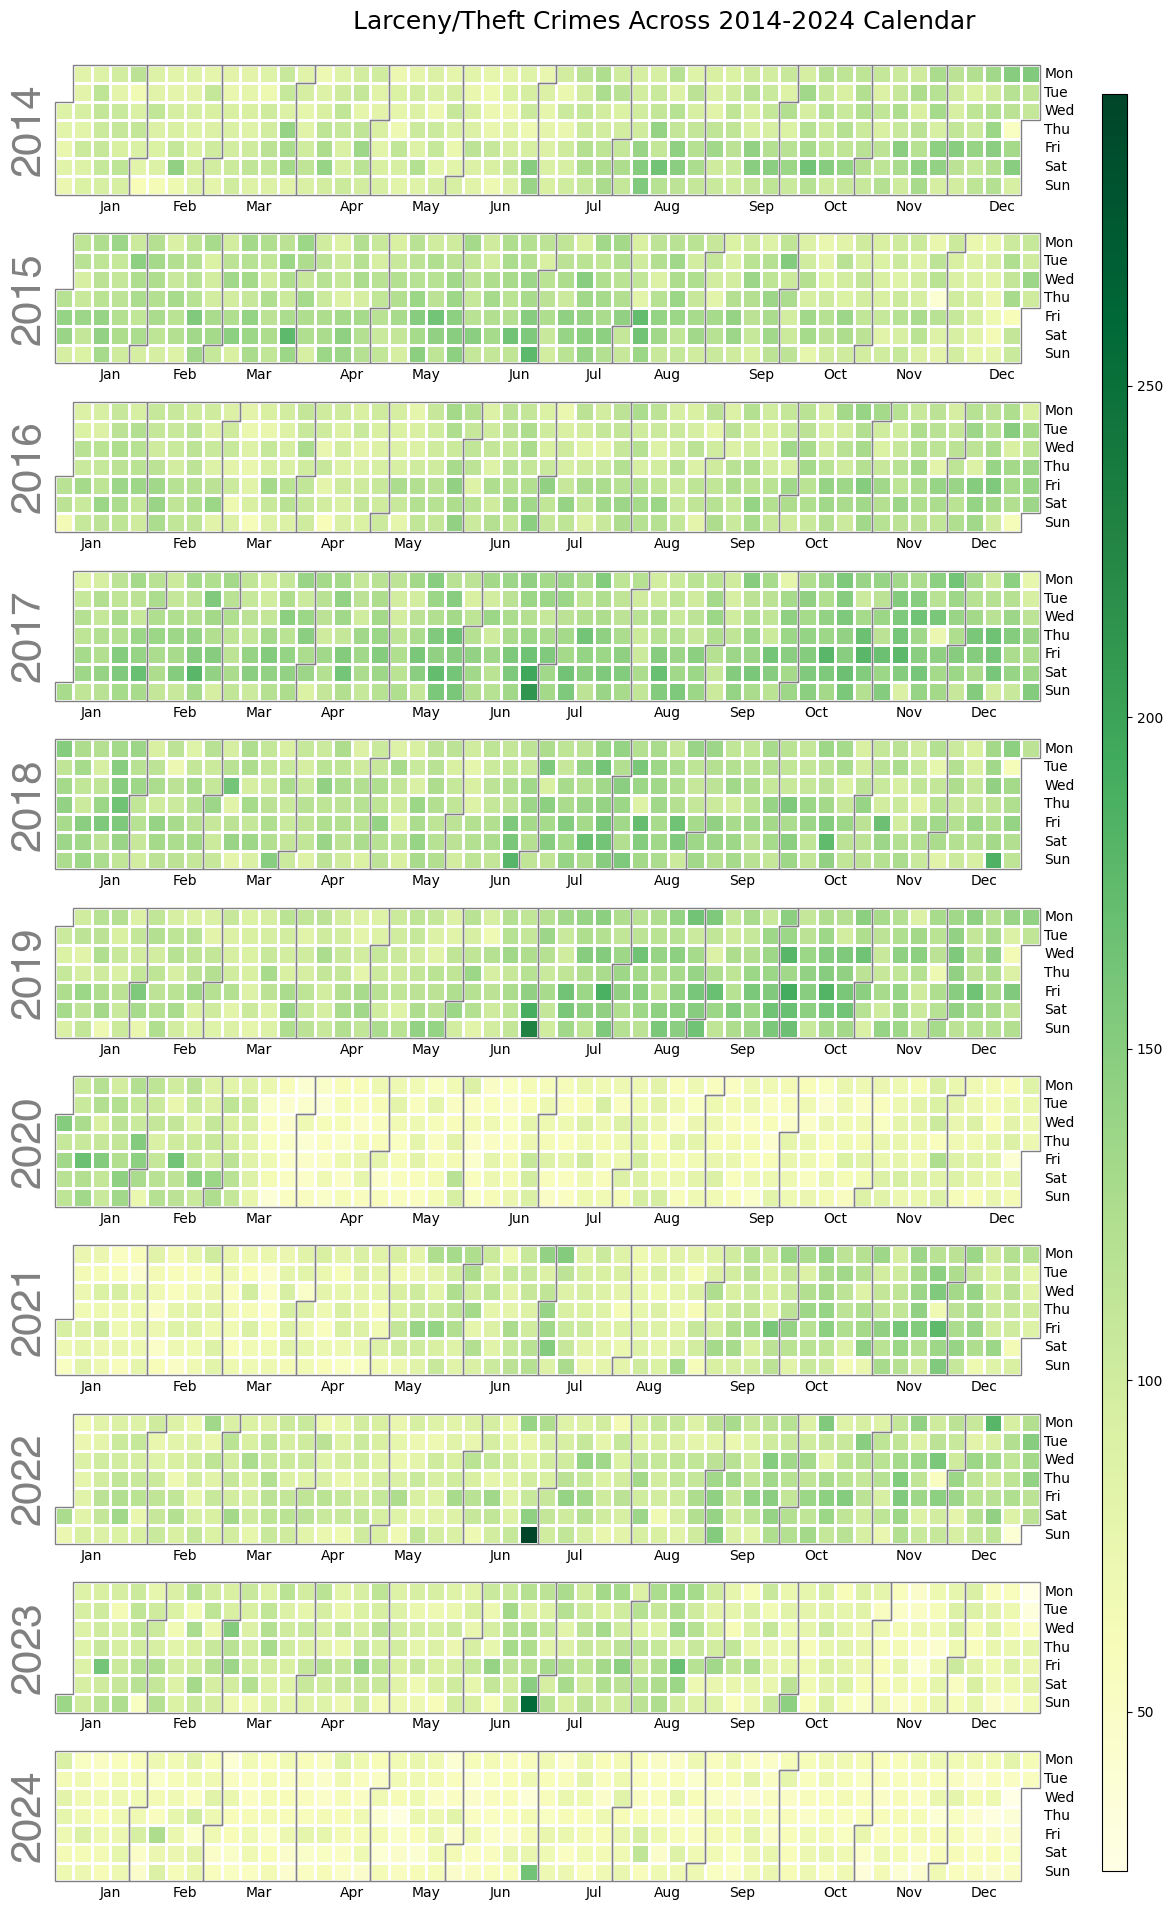

In [17]:
# Count occurrences of crimes category crimes per day
larceny_data['DateOnly'] = larceny_data['Date'].dt.date
crime_counts = larceny_data.groupby('DateOnly').size()

crime_counts.index = pd.to_datetime(crime_counts.index)
plt.figure(figsize=(10, 6))
calplot.calplot(crime_counts, cmap='YlGn') #, colorbar=False)
plt.suptitle('Larceny/Theft Crimes Across 2014-2024 Calendar', fontsize=18, y=1.02)

# Save to folder
output_folder = os.path.expanduser("~/Desktop/uni BA/2nd semester/SDAV/inestacanho.github.io/images")
output_path = os.path.join(output_folder, "crime_calendar_plot.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()